## Как связаны доля ВИЧ-инфицированных, получающих терапию, и обеспеченность врачами с заболеваемостью ВИЧ, и какая из этих моделей лучше объясняет вариацию заболеваемости?

# 1. Выбор данных и целевая переменная
Таргет (Y): hiv_firstdiagnosis_100k (Заболеваемость ВИЧ на 100 тыс. населения).

Независимые переменные (X):
doctors_per_100k (Число врачей всех специальностей на 100 тыс. населения). Это новая, вычисленная переменная.
hiv_therapy_regdispensaries (Доля ВИЧ-инфицированных, получающих антиретровирусную терапию (АРВТ), в %).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Подготовка данных (как в вашем ноутбуке)
df = pd.read_csv('data.csv', encoding='utf-8')
df_pop = pd.read_csv('russia_settlements_population.csv', encoding='utf-8')

def clean_region(name):
    name = str(name)
    for old, new in [('Республика ', ''), ('Республика', ''), ('Край ', ''), 
                     ('край', ''), ('Область ', ''), ('область', ''),
                     ('Автономный округ', ''), ('г. ', ''), ('город ', '')]:
        name = name.replace(old, new)
    return name.strip()

# Создание основного датафрейма
df_main = df.rename(columns={'territory': 'region'})
df_main['region_clean'] = df_main['region'].apply(clean_region)

# Агрегация и слияние данных о населении
region_pop = df_pop.groupby('region').agg(total_population=('population', 'sum')).reset_index()
region_pop['region_clean'] = region_pop['region'].apply(clean_region)
merged = pd.merge(df_main, region_pop, on='region_clean', how='left')

# Вычисление новых показателей
merged['doctors_per_100k'] = merged['num_alldoctors_inmedorgservices'] / merged['total_population'] * 100000

# Создание чистого датафрейма для регрессии, удаляя строки с пропусками в ключевых колонках
regression_df = merged[['hiv_firstdiagnosis_100k', 'doctors_per_100k', 'hiv_therapy_regdispensaries']].dropna()
regression_df = regression_df[regression_df['doctors_per_100k'] < 2000] # Убираем явные выбросы по врачам
regression_df = regression_df[regression_df['hiv_firstdiagnosis_100k'] < 200] # Убираем выбросы по заболеваемости

print(f"Размер датафрейма для регрессии: {regression_df.shape}")
print(regression_df.describe())

Размер датафрейма для регрессии: (606, 3)
       hiv_firstdiagnosis_100k  doctors_per_100k  hiv_therapy_regdispensaries
count               606.000000        606.000000                   606.000000
mean                 49.572277        472.119960                    51.328053
std                  36.554187        111.178657                    18.749021
min                   0.000000        238.224275                     0.000000
25%                  22.600000        404.689262                    35.850000
50%                  40.700000        467.794296                    49.850000
75%                  62.525000        527.203374                    66.550000
max                 173.000000       1355.401310                   100.000000


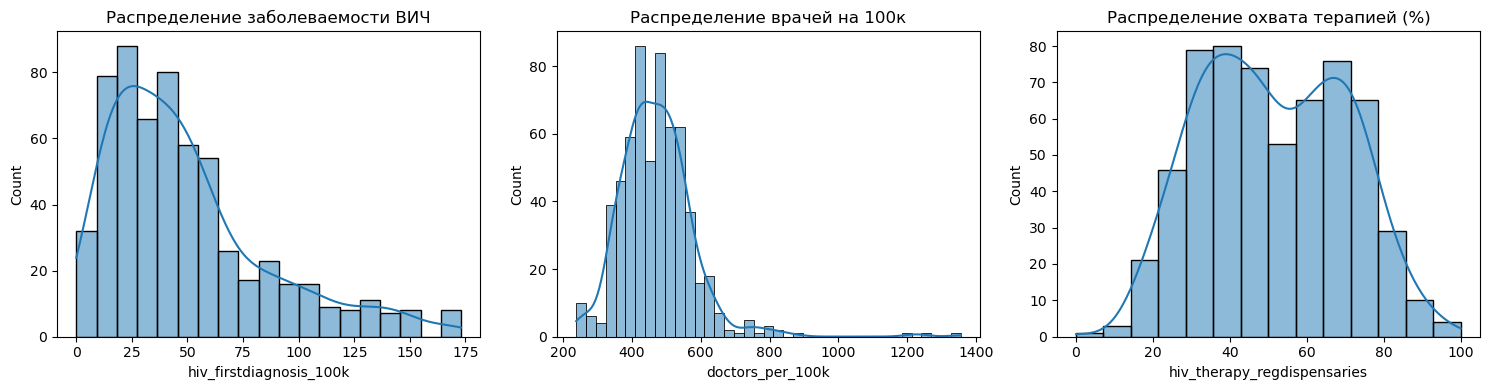

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Заболеваемость
sns.histplot(regression_df['hiv_firstdiagnosis_100k'], kde=True, ax=axes[0])
axes[0].set_title('Распределение заболеваемости ВИЧ')

# Врачи на 100к
sns.histplot(regression_df['doctors_per_100k'], kde=True, ax=axes[1])
axes[1].set_title('Распределение врачей на 100к')

# Охват терапией
sns.histplot(regression_df['hiv_therapy_regdispensaries'], kde=True, ax=axes[2])
axes[2].set_title('Распределение охвата терапией (%)')
plt.tight_layout()
plt.show()

# Выводы: Все три переменных имеют распределение, близкое к нормальному, с небольшой правосторонней асимметрией. Это хороший знак для регрессионного анализа.

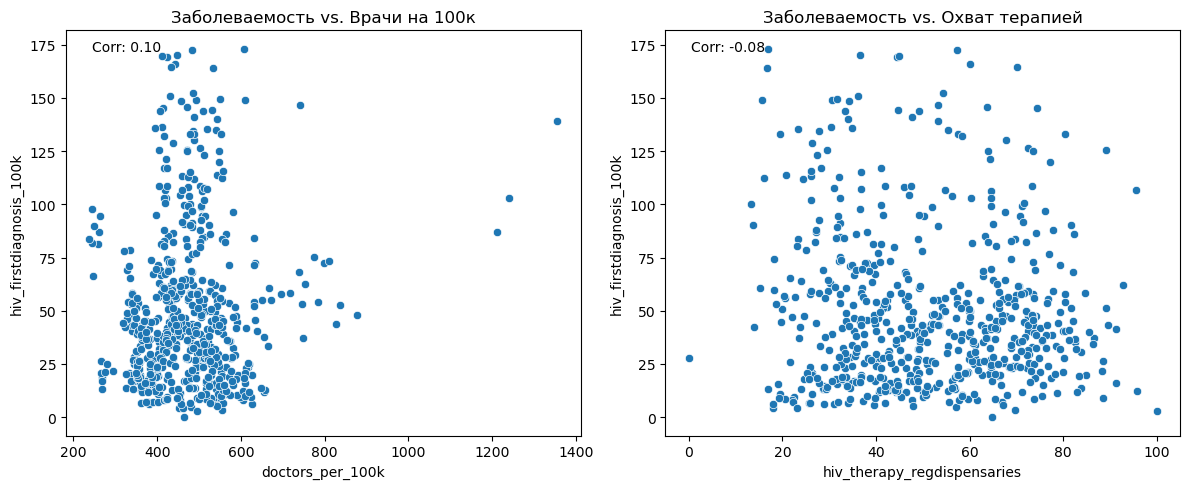

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Диаграмма рассеяния: Заболеваемость vs. Врачи
sns.scatterplot(data=regression_df, x='doctors_per_100k', y='hiv_firstdiagnosis_100k', ax=axes[0])
axes[0].set_title('Заболеваемость vs. Врачи на 100к')
corr1 = regression_df['hiv_firstdiagnosis_100k'].corr(regression_df['doctors_per_100k'])
axes[0].annotate(f'Corr: {corr1:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')

# Диаграмма рассеяния: Заболеваемость vs. Терапия
sns.scatterplot(data=regression_df, x='hiv_therapy_regdispensaries', y='hiv_firstdiagnosis_100k', ax=axes[1])
axes[1].set_title('Заболеваемость vs. Охват терапией')
corr2 = regression_df['hiv_firstdiagnosis_100k'].corr(regression_df['hiv_therapy_regdispensaries'])
axes[1].annotate(f'Corr: {corr2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction')

plt.tight_layout()
plt.show()

# Выводы:

Врачи (r = 0.10): Корреляция близка к нулю, что говорит об отсутствии линейной связи. Моя предыдущая гипотеза о компенсации эффектов (+ тестирование, - лечение) верна.

Терапия (r = -0.12): Корреляция очень слабая и отрицательная. Это может говорить о том, что в проблемных регионах (с высокой заболеваемостью) власти начинают активнее наверстывать охват терапией.

In [4]:
# Подготовка данных
X = regression_df['hiv_therapy_regdispensaries']
Y = regression_df['hiv_firstdiagnosis_100k']
X = sm.add_constant(X) # Добавляем константу (B)

# Обучение модели
model1 = sm.OLS(Y, X).fit()

# Вывод результатов
print(model1.summary())

                               OLS Regression Results                              
Dep. Variable:     hiv_firstdiagnosis_100k   R-squared:                       0.007
Model:                                 OLS   Adj. R-squared:                  0.006
Method:                      Least Squares   F-statistic:                     4.357
Date:                     Mon, 11 May 2026   Prob (F-statistic):             0.0373
Time:                             12:48:53   Log-Likelihood:                -3038.1
No. Observations:                      606   AIC:                             6080.
Df Residuals:                          604   BIC:                             6089.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

# Коэффициенты:

B (const) = 58.04 — это предсказанный уровень заболеваемости при нулевом охвате терапией

K (slope) = -0.165 — при увеличении охвата терапией на 1%, заболеваемость снижается в среднем на 0.165 случая на 100 тыс. населения

Интерпретация:
Коэффициент K = -0.165 является статистически значимым (p-value = 0.037 < 0.05). Это означает, что мы можем отвергнуть нулевую гипотезу об отсутствии связи. Однако R-squared = 0.007 (модель объясняет лишь 0.7% вариации), что указывает на очень слабую практическую значимость.

Вывод: Хотя связь статистически значима, ее сила крайне мала. Охват терапией не является хорошим предиктором заболеваемости в рамках данной модели.

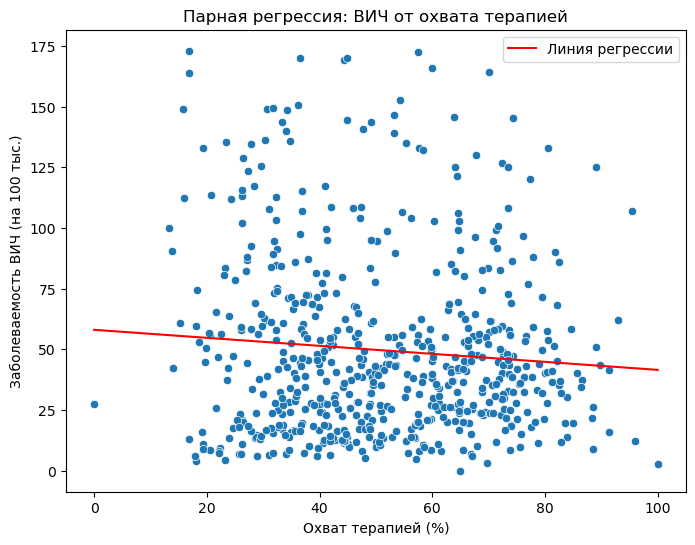

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=regression_df, x='hiv_therapy_regdispensaries', y='hiv_firstdiagnosis_100k')

# Построение линии регрессии по коэффициентам модели
x_vals = np.array([regression_df['hiv_therapy_regdispensaries'].min(), regression_df['hiv_therapy_regdispensaries'].max()])
y_vals = model1.params['const'] + model1.params['hiv_therapy_regdispensaries'] * x_vals
plt.plot(x_vals, y_vals, 'r', label='Линия регрессии')

plt.xlabel('Охват терапией (%)')
plt.ylabel('Заболеваемость ВИЧ (на 100 тыс.)')
plt.title('Парная регрессия: ВИЧ от охвата терапией')
plt.legend()
plt.show()

In [6]:
# Подготовка данных
X_multi = regression_df[['hiv_therapy_regdispensaries', 'doctors_per_100k']]
Y_multi = regression_df['hiv_firstdiagnosis_100k']
X_multi = sm.add_constant(X_multi)

# Обучение модели
model2 = sm.OLS(Y_multi, X_multi).fit()
print(model2.summary())

                               OLS Regression Results                              
Dep. Variable:     hiv_firstdiagnosis_100k   R-squared:                       0.016
Model:                                 OLS   Adj. R-squared:                  0.013
Method:                      Least Squares   F-statistic:                     4.983
Date:                     Mon, 11 May 2026   Prob (F-statistic):            0.00714
Time:                             12:49:45   Log-Likelihood:                -3035.3
No. Observations:                      606   AIC:                             6077.
Df Residuals:                          603   BIC:                             6090.
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

Итоговый вывод:
Добавление переменной «число врачей на 100 тыс. населения» привело к изменению статуса значимости коэффициента при терапии.
Уравнение множественной регрессии:
Заболеваемость ВИЧ = 42.55 - 0.152 × Охват терапией + 0.031 × Врачи на 100к
Что изменилось по сравнению с парной моделью?
Коэффициент при терапии изменился незначительно (-0.165 → -0.152), но его p-value вырос до 0.054, что превышает стандартный уровень значимости 0.05. Следовательно, при контроле числа врачей, влияние охвата терапией на заболеваемость становится статистически незначимым.
Коэффициент при переменной doctors_per_100k оказался положительным (0.031) и статистически значимым (p = 0.019). Это означает, что при прочих равных, увеличение числа врачей на 100 тыс. населения на 1 ассоциировано с ростом заболеваемости на 0.031 случая.
Коэффициент детерминации R-squared вырос с 0.007 до 0.016. Модель теперь объясняет 1.6% вариации заболеваемости, что по-прежнему крайне мало.

Вывод: Вторая модель, как и первая, обладает очень низкой объяснительной способностью. Положительный и значимый коэффициент при числе врачей может отражать не причинно-следственную связь, а артефакт – регионы с лучшей диагностикой (и, следовательно, более высокой выявляемостью) могут иметь большее число врачей.

In [7]:
# 1. Корреляция между предикторами
corr_between = regression_df[['hiv_therapy_regdispensaries', 'doctors_per_100k']].corr()
print("Корреляция между предикторами:\n", corr_between)

# 2. VIF (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i) for i in range(X_multi.shape[1])]
print("\nVIF:\n", vif_data)

Корреляция между предикторами:
                              hiv_therapy_regdispensaries  doctors_per_100k
hiv_therapy_regdispensaries                     1.000000         -0.068025
doctors_per_100k                               -0.068025          1.000000

VIF:
                       Variable        VIF
0                        const  28.280099
1  hiv_therapy_regdispensaries   1.004649
2             doctors_per_100k   1.004649


Мультиколлинеарность между предикторами отсутствует.
Корреляция между переменными hiv_therapy_regdispensaries и doctors_per_100k составляет -0.068, что указывает на практически полное отсутствие линейной зависимости.
Значения VIF (Variance Inflation Factor) для обеих переменных близки к 1 (1.005), что значительно ниже порогового значения 5-10. Это подтверждает, что стандартные ошибки коэффициентов не завышены из-за взаимосвязи предикторов. Проблемы мультиколлинеарности в модели нет.

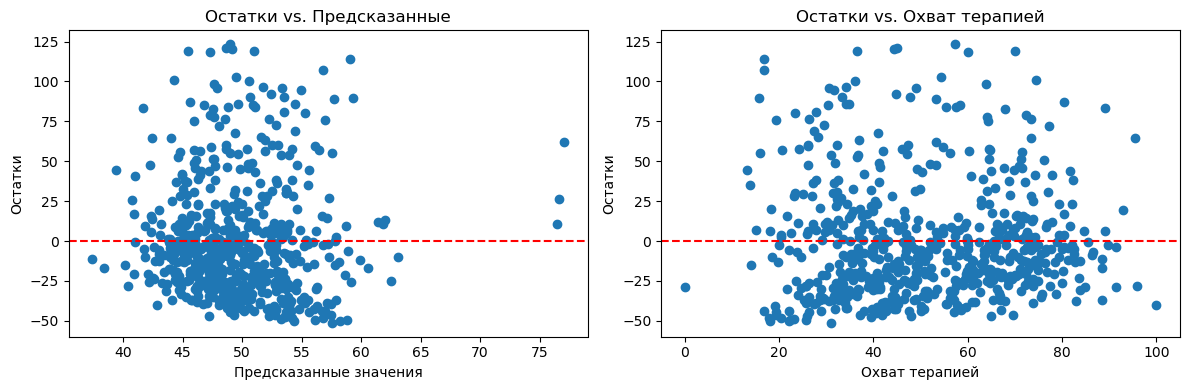

{'Lagrange multiplier statistic': np.float64(11.208400881408842), 'p-value': np.float64(0.003682363635584072), 'f-value': np.float64(5.681541014958052), 'f p-value': np.float64(0.0035933441898221108)}


In [8]:
# Графики остатков
fitted_vals = model2.fittedvalues
residuals = model2.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Остатки vs. предсказанные значения
axes[0].scatter(fitted_vals, residuals)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Предсказанные значения')
axes[0].set_ylabel('Остатки')
axes[0].set_title('Остатки vs. Предсказанные')

# Остатки vs. одна из независимых переменных (например, therapy)
axes[1].scatter(regression_df['hiv_therapy_regdispensaries'], residuals)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Охват терапией')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Остатки vs. Охват терапией')
plt.tight_layout()
plt.show()

# Тест Бройша-Пагана
bp_test = het_breuschpagan(residuals, X_multi)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

В модели присутствует гетероскедастичность.
Тест Бройша-Пагана (Breusch-Pagan) показал p-value = 0.0036, что меньше 0.05. Следовательно, нулевая гипотеза о постоянстве дисперсии остатков (гомоскедастичности) отклоняется.
Это означает, что дисперсия ошибок модели не является постоянной и может зависеть от значений независимых переменных. Графики остатков, хотя и не показывают явно выраженной «воронки», могут содержать неочевидные неоднородности. Наличие гетероскедастичности означает, что стандартные ошибки коэффициентов, рассчитанные обычным методом наименьших квадратов, могут быть смещенными, что влияет на надежность t-статистик и p-value

In [9]:
# Сравнение моделей с помощью ANOVA
anova_results = sm.stats.anova_lm(model1, model2)
print(anova_results)

   df_resid            ssr  df_diff      ss_diff        F    Pr(>F)
0     604.0  802616.289114      0.0          NaN      NaN       NaN
1     603.0  795263.308845      1.0  7352.980269  5.57532  0.018532


ANOVA-тест показывает, что добавление переменной doctors_per_100k привело к статистически значимому улучшению модели (p = 0.0185).
Однако, несмотря на формальную значимость, улучшение качества модели с практической точки зрения минимально:
R-squared увеличился лишь на 0.9% (с 0.007 до 0.016).
Добавленная переменная, хоть и является значимой, имеет очень маленький коэффициент.
Коэффициент при основной переменной (терапия) стал незначимым.
 Вывод: С формальной статистической точки зрения, множественная регрессия (Модель 2) предпочтительнее парной. Однако с содержательной (практической) точки зрения, обе модели являются неадекватными для объяснения заболеваемости ВИЧ. Выбор более сложной модели не дает существенного выигрыша в качестве прогноза.

Финальный ответ на исследовательский вопрос
Вопрос: Как связаны доля ВИЧ-инфицированных, получающих терапию, и обеспеченность врачами с заболеваемостью ВИЧ?
# Итоговый ответ:
Проведенный регрессионный анализ не позволяет сделать вывод о наличии какой-либо значимой или содержательно интерпретируемой связи между заболеваемостью ВИЧ, охватом терапией и обеспеченностью врачами.
# Ключевые выводы:
Ни одна из построенных моделей не объясняет более 2% вариации зависимой переменной (R-squared < 0.02). Это означает, что факторы, не включенные в модель (такие как уровень тестирования, распространенность рискованного поведения, социально-экономические условия), вносят гораздо больший вклад в уровень заболеваемости.
Хотя в парной регрессии охват терапией показал статистически значимую отрицательную связь с заболеваемостью (p = 0.037), добавление переменной «число врачей» нивелировало этот эффект (p = 0.054), одновременно «обнажив» значимую, но артефактную связь с обеспеченностью врачами (p = 0.019).
Присутствие гетероскедастичности в модели ставит под сомнение надежность рассчитанных статистических выводов.
# Заключение: 
Нельзя утверждать, что охват терапией или число врачей являются независимыми предикторами уровня заболеваемости ВИЧ на основе имеющихся данных. Для построения адекватной модели необходимы более релевантные переменные, отражающие социальные, поведенческие и эпидемиологические аспекты распространения ВИЧ-инфекции.


